# Predicting Airbnb Occupancy and Pricing Using Listing and Neighborhood Demographic Data

**Authors:** Roman Shrestha and Tanish Pradhan Wong Ah Sui

**Course:** CMPU 395, Machine Learning

Notebook of all analysis for the project.

## 1. Setup

Imports for the whole notebook. We use `random_state=395` everywhere.

In [39]:
# make sure paths work from project root or from final-draft/
import os
if not os.path.exists("data/airbnb_cleaned_part1.csv"):
    os.chdir("..")
print("working directory:", os.getcwd())

working directory: /Users/roman/Documents/VassarClasses/Spring 2026/ML/airbnb-equity-ml-main


In [40]:
#import libraries

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             accuracy_score, classification_report, roc_auc_score)

import xgboost as xgb
import lightgbm as lgb
import shap

SEED = 395
OUT = "progress_report"

## 2. Data description and loading

In [41]:
#read csvs

df1 = pd.read_csv("data/airbnb_cleaned_part1.csv", index_col=0)
df2 = pd.read_csv("data/airbnb_cleaned_part2.csv", index_col=0)
df = pd.concat([df1, df2], ignore_index=True)
print("shape:", df.shape)

shape: (280286, 61)


## 3. Cleaning and preparation

We did several rounds of cleaning. The basics: standardizing column names across the city files,
dropping fully empty or near constant columns, and parsing booleans (`host_is_superhost`,
`instant_bookable`, etc.) which were inconsistently encoded as `True`/`False`/`t`/`f`/`0`/`1`
across files.

We found that: 

- `host_response_rate` and `host_acceptance_rate` come in as strings like `"95%"`. We strip `%` and
  divide by 100.
- The ACS `median_age` column has negative numbers used to flag missing values.
  We replace these with NaN.
- `property_type` has many categories, so we collapse to the top 5 plus an "other" bucket.

Missing data turned out to be the big preparation challenge. 
 **43.1% of listings are missing the price field**, **20.7% are missing review scores**,
and four cities (LA, NYC, San Francisco, Portland) have no price data at all in the files we
downloaded, so the price model effectively excludes those four cities.

In [42]:
# fix the median_age
df["median_age"] = df["median_age"].where(df["median_age"] > 0, other=np.nan)

# percent strings -> proportions
for c in ["host_response_rate", "host_acceptance_rate"]:
    df[c] = df[c].astype(str).str.rstrip("%").replace("nan", np.nan)
    df[c] = pd.to_numeric(df[c], errors="coerce") / 100.0

# bool cols normalize them
bool_cols = ["host_identity_verified", "host_has_profile_pic",
             "instant_bookable", "host_is_superhost"]
for c in bool_cols:
    df[c] = df[c].map({True: 1, False: 0, "True": 1, "False": 0,
                       "t": 1, "f": 0, 1: 1, 0: 0})
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0).astype(int)

# group rare property types
top_props = df["property_type"].value_counts().head(5).index
df["property_type_grouped"] = df["property_type"].where(df["property_type"].isin(top_props), "other")
print("property type buckets:", df["property_type_grouped"].value_counts().to_dict())

property type buckets: {'entire_home': 209932, 'private_room': 53487, 'hotel': 13230, 'other': 2379, 'shared_room': 1258}


### Missingness summary

Price/revenue missingness is the big problem. Review scores are missing for ~21% of listings
(mostly listings with zero reviews).

In [43]:
key_cols = ["price", "estimated_occupancy_l365d", "estimated_revenue_l365d",
            "review_scores_rating", "median_household_income", "poverty_rate",
            "pct_white", "pct_black", "pct_hispanic", "pct_college_educated"]
miss = df[key_cols].isnull().sum()
miss_pct = (miss / len(df) * 100).round(2)
pd.DataFrame({"count": miss, "pct": miss_pct}).sort_values("pct", ascending=False)

,count,pct
price,120683,43.06
estimated_revenue_l365d,120683,43.06
review_scores_rating,58039,20.71
median_household_income,829,0.30
estimated_occupancy_l365d,0,0.00
poverty_rate,0,0.00
pct_white,0,0.00
pct_black,0,0.00
pct_hispanic,0,0.00
pct_college_educated,0,0.00


### Summary statistics

Numeric summary of the variables we use most. `price` is right-skewed (mean $221, median $161) and
`estimated_occupancy_l365d` ranges 0-255 nights with median 30.

In [44]:
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols].describe().T[["mean", "std", "min", "50%", "max"]].round(2) #summary statistics

,mean,std,min,50%,max
price,2.215200e+02,1.828000e+02,0.000000e+00,1.610000e+02,7.679500e+02
estimated_occupancy_l365d,7.312000e+01,8.890000e+01,0.000000e+00,3.000000e+01,2.550000e+02
estimated_revenue_l365d,1.455383e+04,1.682327e+04,0.000000e+00,8.160000e+03,5.762610e+04
review_scores_rating,4.780000e+00,3.900000e-01,0.000000e+00,4.890000e+00,5.000000e+00
reviews_per_month,1.500000e+00,1.860000e+00,1.000000e-02,9.100000e-01,1.203700e+02
accommodates,4.400000e+00,3.040000e+00,1.000000e+00,4.000000e+00,1.600000e+01
bedrooms,1.790000e+00,1.340000e+00,0.000000e+00,1.000000e+00,5.700000e+01
beds,2.320000e+00,1.940000e+00,0.000000e+00,2.000000e+00,1.530000e+02
minimum_nights,1.427000e+01,2.732000e+01,1.000000e+00,3.000000e+00,1.125000e+03
maximum_nights,2.648300e+02,1.459300e+02,1.000000e+00,3.650000e+02,3.650000e+02


## 4. Exploratory data analysis

We do six visualisations: target distributions, a correlation heatmap, room-type comparison,
demographics-vs-price scatter, listings per city, and demographics-vs-occupancy scatter.

### Figure 1 - target distributions

Price is right-skewed with a long tail. Estimated revenue follows a similar shape. Occupancy is
bimodal: a big mass near zero (inactive listings) and a smaller cluster at high occupancy
(professionally managed listings). This is why we treat occupancy as a classification problem
instead of regression.

with valid price: 159602


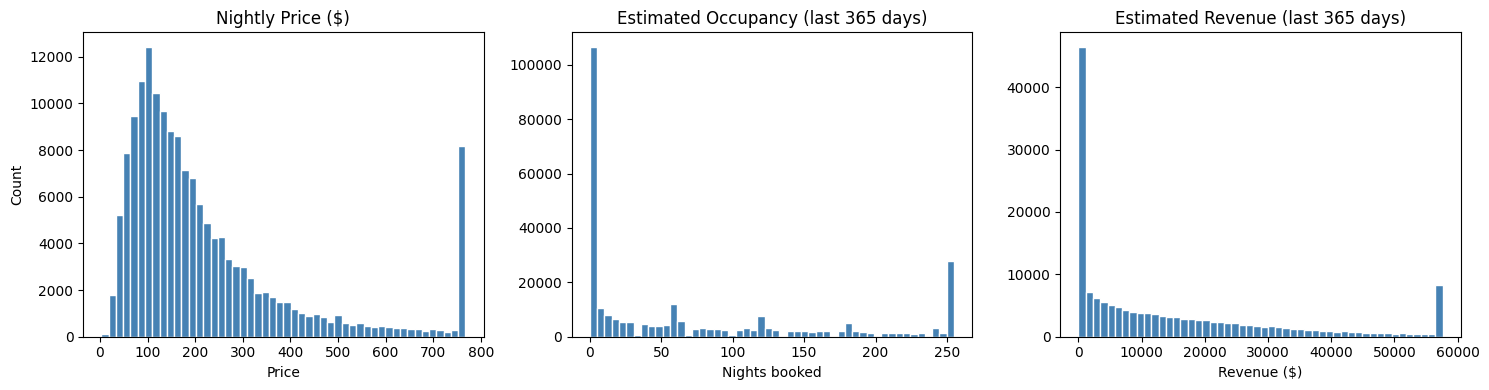

In [45]:
df_price = df.dropna(subset=["price"])
df_price = df_price[df_price["price"] > 0]
print("with valid price:", len(df_price))

#histograms
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(df_price["price"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Nightly Price ($)"); axes[0].set_xlabel("Price"); axes[0].set_ylabel("Count")

axes[1].hist(df["estimated_occupancy_l365d"], bins=50, color="steelblue", edgecolor="white")
axes[1].set_title("Estimated Occupancy (last 365 days)"); axes[1].set_xlabel("Nights booked")

df_rev = df.dropna(subset=["estimated_revenue_l365d"])
axes[2].hist(df_rev["estimated_revenue_l365d"], bins=50, color="steelblue", edgecolor="white")
axes[2].set_title("Estimated Revenue (last 365 days)"); axes[2].set_xlabel("Revenue ($)")

plt.tight_layout(); plt.savefig("figures/fig1_target_distributions.png", dpi=150, bbox_inches="tight"); plt.show()

### Figure 2 - correlation heatmap

Some takeaways from the matrix:

- Price correlates with `accommodates` (0.52), `bedrooms` (0.44), and `median_home_value` (0.27).
- Revenue and occupancy have a strong correlation (0.83) by construction.
- `pct_white` and `pct_black` are negatively correlated (-0.52). They behave like substitute shares
  of the tract.
- `median_household_income` correlates positively with `pct_white` and `pct_college_educated`.

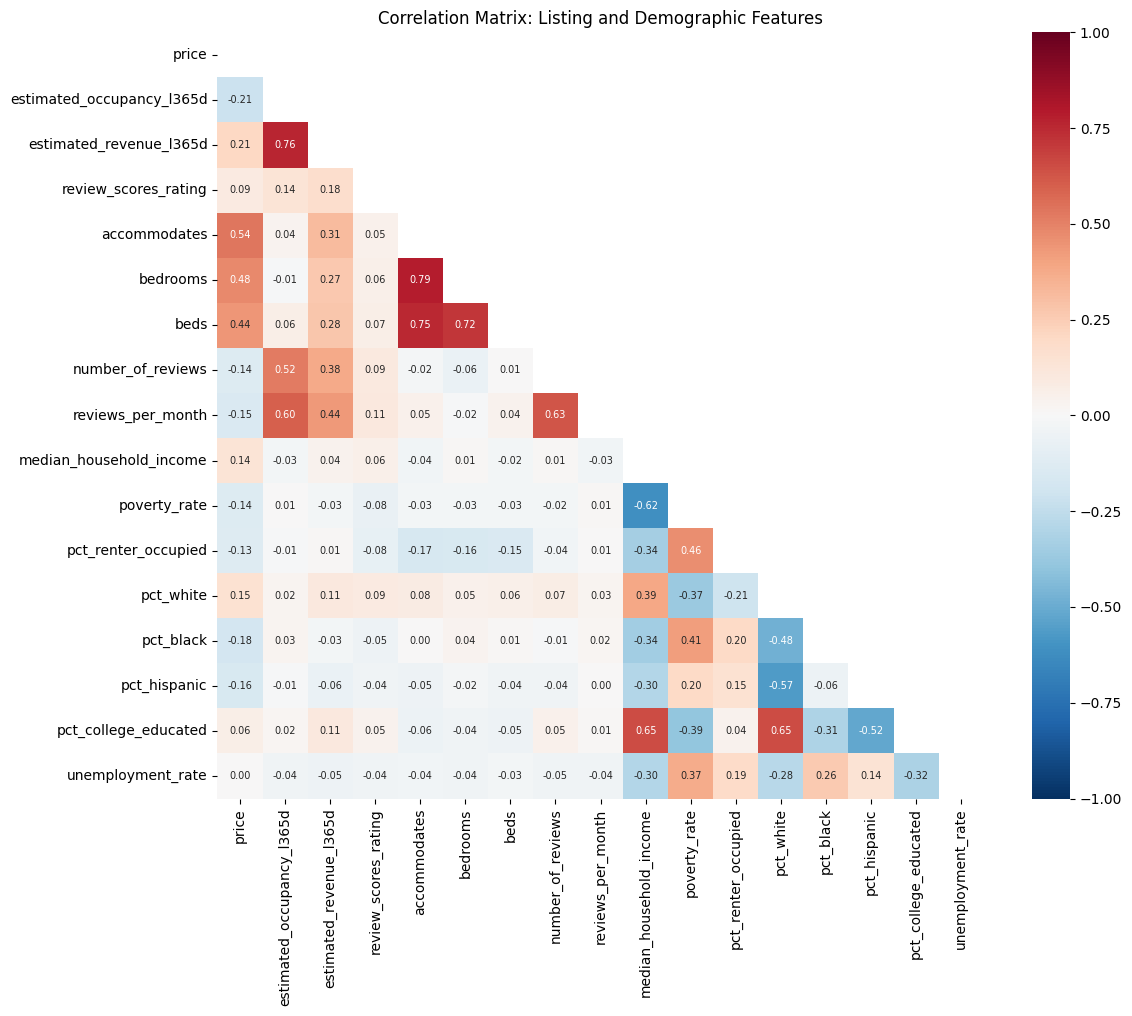

In [46]:
corr_cols = ["price", "estimated_occupancy_l365d", "estimated_revenue_l365d",
             "review_scores_rating", "accommodates", "bedrooms", "beds",
             "number_of_reviews", "reviews_per_month",
             "median_household_income", "poverty_rate", "pct_renter_occupied",
             "pct_white", "pct_black", "pct_hispanic", "pct_college_educated",
             "unemployment_rate"]
corr = df[corr_cols].corr() #calculate correlations

#heatmap
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=ax, square=True, annot_kws={"size": 7})
ax.set_title("Correlation Matrix: Listing and Demographic Features")
plt.tight_layout(); plt.savefig("figures/fig2_correlation_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()

### Figure 3 - room type

Entire homes are pricier and have more occupancy than private rooms or shared rooms. Hotel rooms
sit between entire homes and private rooms in price.

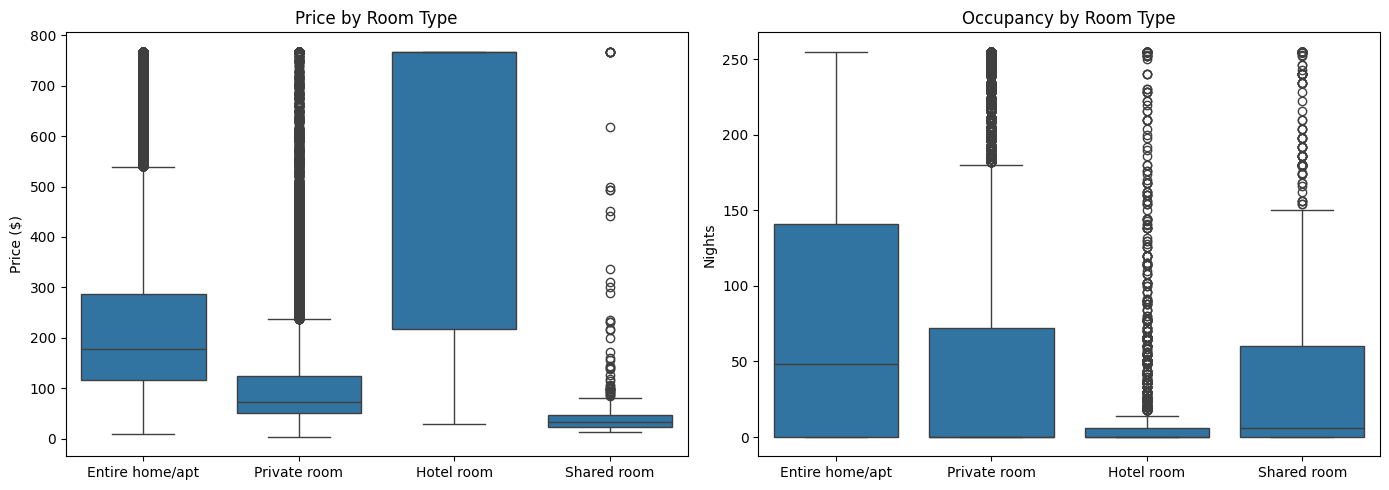

In [47]:
#plot boxplots by room type for price and occupancy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order = df_price["room_type"].value_counts().index.tolist()
sns.boxplot(data=df_price, x="room_type", y="price", order=order, ax=axes[0])
axes[0].set_title("Price by Room Type"); axes[0].set_xlabel(""); axes[0].set_ylabel("Price ($)")

sns.boxplot(data=df, x="room_type", y="estimated_occupancy_l365d", order=order, ax=axes[1])
axes[1].set_title("Occupancy by Room Type"); axes[1].set_xlabel(""); axes[1].set_ylabel("Nights")
plt.tight_layout(); plt.savefig("figures/fig3_room_type.png", dpi=150, bbox_inches="tight"); plt.show()

### Figure 4 - demographic features vs price

Higher median household income and college education are associated with higher prices. Poverty rate
shows the opposite pattern. The %Black correlation with price is small (~ -0.06 raw) but visible. We
come back to this in section 11.

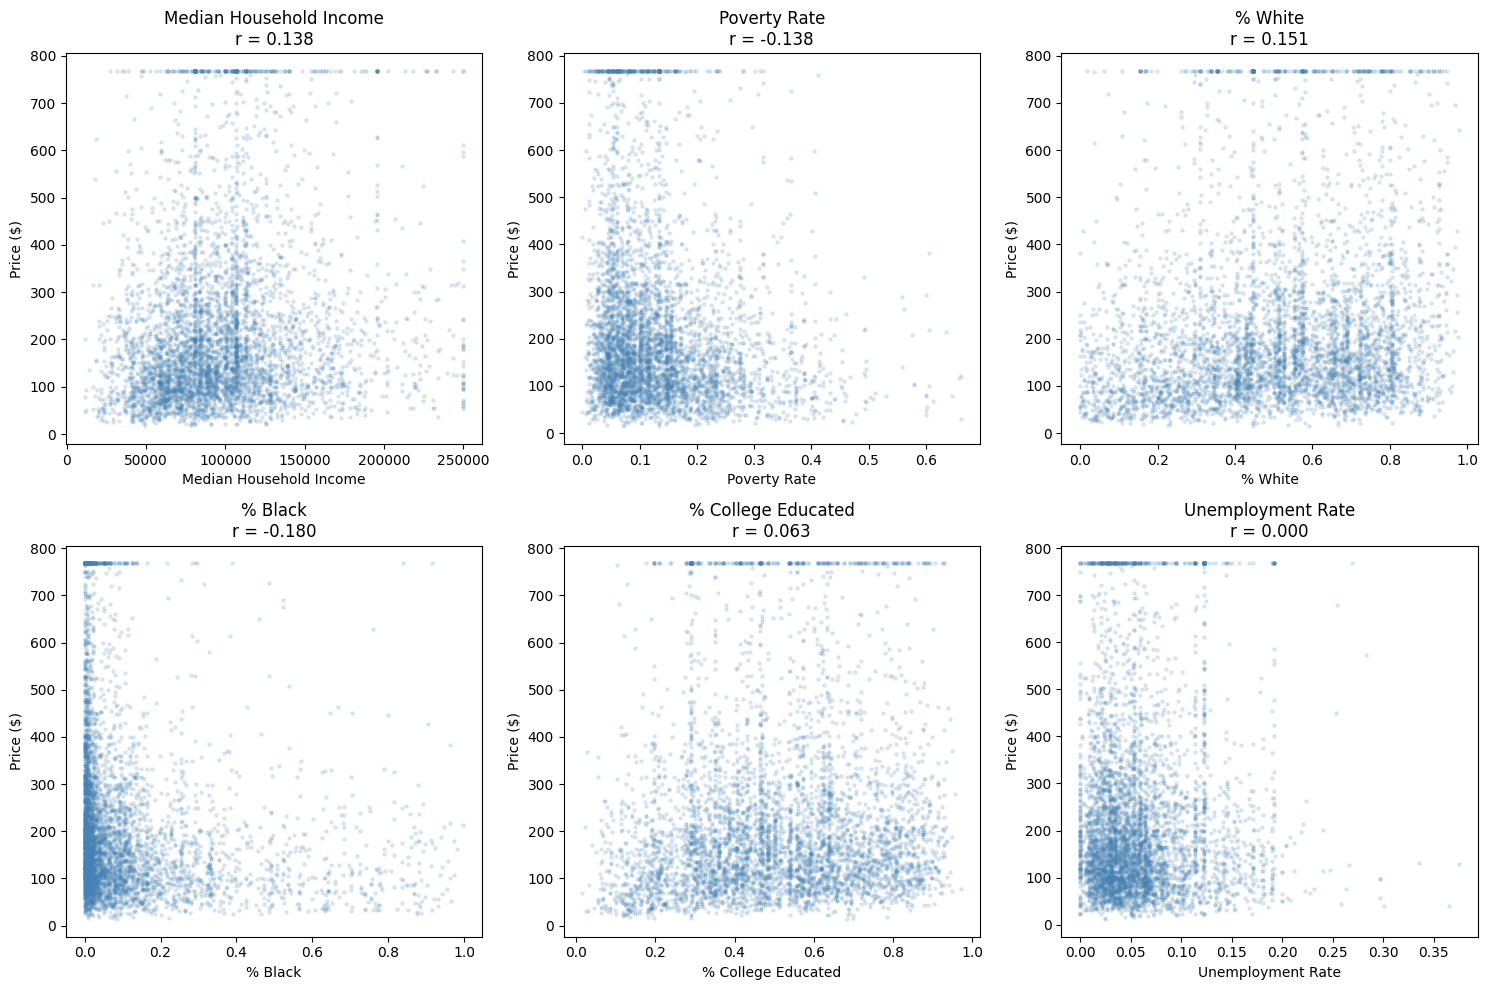

In [ ]:
demo_cols = ["median_household_income", "poverty_rate", "pct_white",
             "pct_black", "pct_college_educated", "unemployment_rate"]
demo_labels =["Median Household Income", "Poverty Rate", "% White",
               "% Black", "% College Educated", "Unemployment Rate"]

#scatterplots for demographic features vs price
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax,col,lbl in zip(axes.flatten(), demo_cols, demo_labels):
    samp = df_price.dropna(subset=[col]).sample(min(5000, len(df_price)), random_state=SEED)
    ax.scatter(samp[col], samp["price"], alpha=0.15, s=5, color="steelblue")
    r = df_price[[col, "price"]].dropna().corr().iloc[0, 1]
    ax.set_xlabel(lbl); ax.set_ylabel("Price ($)"); ax.set_title(f"{lbl}\nr = {r:.3f}")
plt.tight_layout(); plt.savefig("figures/fig4_demographics_vs_price.png", dpi=150, bbox_inches="tight"); plt.show()

### Figure 5 - listings by city

LA, NYC, and Hawaii dominate the listings count. As noted above, LA and NYC have no valid price
field in the files we downloaded, so the price-side analysis below is missing two of the largest
markets.

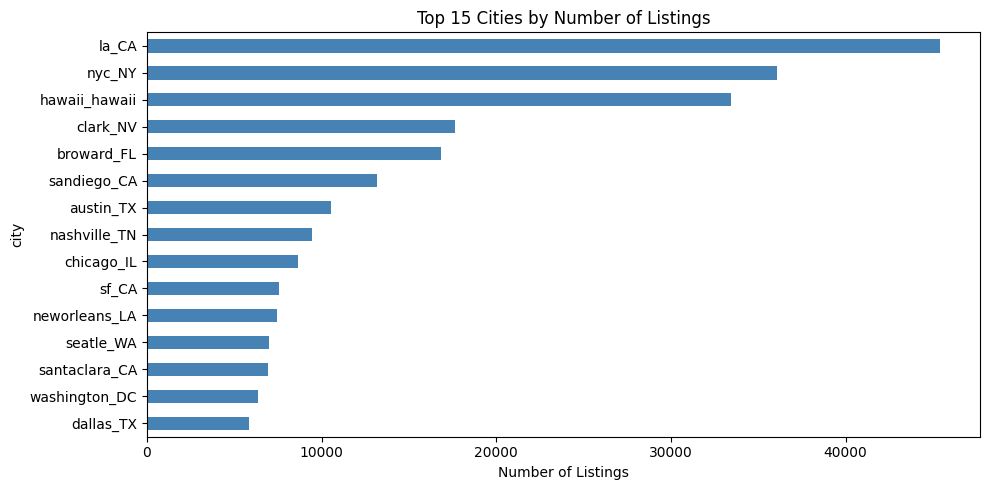

In [ ]:
fig,ax = plt.subplots(figsize=(10, 5))
df["city"].value_counts().head(15).plot(kind="barh", color="steelblue", ax=ax)
ax.set_xlabel("Number of Listings"); ax.set_title("Top 15 Cities by Number of Listings")
ax.invert_yaxis()
plt.tight_layout(); plt.savefig("figures/fig5_city_counts.png", dpi=150, bbox_inches="tight"); plt.show()

### Figure 6 - demographic features vs occupancy

The raw correlations with occupancy are weaker than with price. Visually nothing is seen clearly. This is an
early hint that listing-level signals like reviews and host responsiveness dominate occupancy
prediction, not demographics.

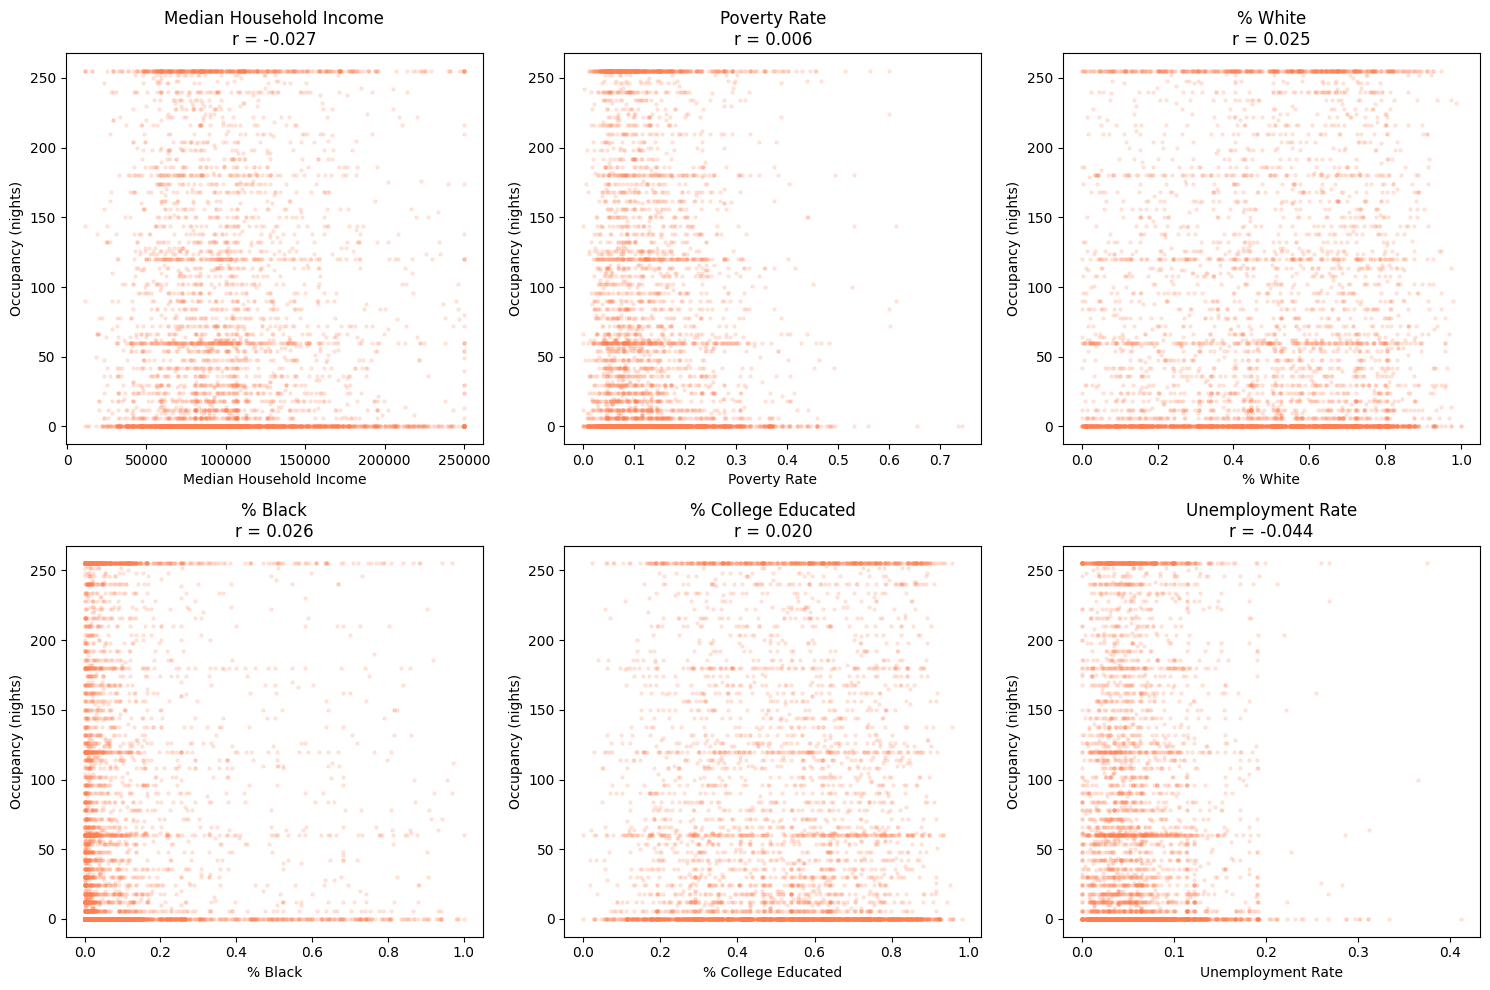

In [ ]:
# scatterplots for demographic features vs occupancy
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, col, lbl in zip(axes.flatten(), demo_cols, demo_labels):
    samp = df.dropna(subset=[col]).sample(min(5000, len(df)), random_state=SEED)
    ax.scatter(samp[col], samp["estimated_occupancy_l365d"], alpha=0.15, s=5, color="coral")
    r = df[[col, "estimated_occupancy_l365d"]].dropna().corr().iloc[0, 1]
    ax.set_xlabel(lbl); ax.set_ylabel("Occupancy (nights)"); ax.set_title(f"{lbl}\nr = {r:.3f}")
plt.tight_layout();plt.savefig("figures/fig6_demographics_vs_occupancy.png", dpi=150, bbox_inches="tight"); plt.show()

## 5. Methods

The project has two prediction tasks.

**Price (regression).** Predict per-night listing price from listing + demographic features. Price is
heavily right-skewed, so we use `log1p(price)` as the target. RMSE is reported in dollar space (after
inverse-transforming).

**Occupancy (classification).** Predict whether a listing is "high occupancy" (above the dataset
median of 30 nights/year). Occupancy is bimodal with a big spike at zero and another cluster up high,
which makes a regression model a poor fit. We use a binary threshold instead.

For each task we fit a linear baseline (linear / logistic), random forest, XGBoost, and LightGBM. For
price we also do an ablation: listing-only vs listing+demographic features. We use a 80/20 train/test
split with `random_state=395`.

### Feature preparation

We split features into two groups: listing-level (size, amenities, host attributes, review scores)
and demographic (tract-level ACS variables). `room_type` and the grouped `property_type` get
one-hot encoded.

In [ ]:
listing_features = [
    "accommodates", "bedrooms", "beds", "bathrooms",
    "minimum_nights", "maximum_nights",
    "availability_365", "availability_30",
    "number_of_reviews", "reviews_per_month",
    "review_scores_rating", "review_scores_cleanliness",
    "review_scores_location","review_scores_value",
    "host_response_time", "host_response_rate", "host_acceptance_rate",
    "calculated_host_listings_count",
    "has_wifi", "has_parking", "has_pool", "has_gym",
    "instant_bookable", "host_is_superhost",
    "host_identity_verified", "host_has_profile_pic"
]
demo_features = [
    "median_household_income", "median_gross_rent", "median_home_value",
    "total_population","median_age", "poverty_rate",
    "pct_renter_occupied", "pct_white", "pct_black",
    "pct_asian", "pct_hispanic","pct_college_educated",
    "unemployment_rate"
]

#create dummy variables
room_dummies = pd.get_dummies(df["room_type"], prefix="room", drop_first=True)
prop_dummies = pd.get_dummies(df["property_type_grouped"], prefix="prop", drop_first=True)

#concatenate listing and demographic features
feat = pd.concat([df[listing_features + demo_features], room_dummies, prop_dummies], axis=1)
bcols = feat.select_dtypes(include=["bool"]).columns
feat[bcols] = feat[bcols].astype(int)
print("total features:", feat.shape[1])

total features: 46


### 5.1 Price prediction baselines

For the price baseline we drop rows with any missing feature (we revisit imputation in later sections).
This gives 128,078 listings with no missing values, predicting `log1p(price)`.

In [52]:
price_mask = df["price"].notna() & (df["price"] > 0)
X = feat[price_mask].copy()
y = np.log1p(df.loc[price_mask, "price"])

# median imputation
ok = X.notna().all(axis=1)
X = X[ok]; y = y[ok]
X = X.fillna(X.median())  
print("samples:", len(X))

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=SEED)
y_te_actual = np.expm1(y_te)

samples: 128078


**Linear regression baseline.**

In [ ]:
sc = StandardScaler()
X_tr_s = sc.fit_transform(X_tr)
X_te_s = sc.transform(X_te)

# fit the linear regression model
lr = LinearRegression()
lr.fit(X_tr_s, y_tr)
y_pred_lr = lr.predict(X_te_s)
y_pred_lr_actual = np.expm1(y_pred_lr)

# calculate error metrics
rmse_lr = np.sqrt(mean_squared_error(y_te_actual,y_pred_lr_actual))
mae_lr = mean_absolute_error(y_te_actual, y_pred_lr_actual)
r2_lr = r2_score(y_te, y_pred_lr)

print(f"linear: R2={r2_lr:.4f}  RMSE=${rmse_lr:.2f}  MAE=${mae_lr:.2f}")

coef_df = pd.DataFrame({"feature": X_tr.columns, "coefficient": lr.coef_})
coef_df.sort_values("coefficient", key=abs, ascending=False).head(10)

linear: R2=0.6226  RMSE=$275.79  MAE=$72.68


,feature,coefficient
0,accommodates,0.212876
44,prop_private_room,-0.170515
34,pct_black,-0.168116
36,pct_hispanic,-0.163864
1,bedrooms,0.132885
33,pct_white,-0.132719
41,room_Shared room,-0.117983
28,median_home_value,0.113561
35,pct_asian,-0.099262
13,review_scores_value,-0.096875


**Random forest.** Better than linear because it handles non-linear interactions and the right tail.

In [ ]:
# fit random forest model
rf_reg = RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_leaf=10,
                               random_state=SEED, n_jobs=-1)
rf_reg.fit(X_tr, y_tr)
y_pred_rf = rf_reg.predict(X_te)
y_pred_rf_actual = np.expm1(y_pred_rf)

# error metrics
rmse_rf = np.sqrt(mean_squared_error(y_te_actual, y_pred_rf_actual))
mae_rf = mean_absolute_error(y_te_actual, y_pred_rf_actual)
r2_rf = r2_score(y_te, y_pred_rf)
print(f"rf: R2={r2_rf:.4f} RMSE=${rmse_rf:.2f} MAE=${mae_rf:.2f}")

importance_df = pd.DataFrame({"feature": X_tr.columns,
                              "importance": rf_reg.feature_importances_})
importance_df = importance_df.sort_values("importance", ascending=False)
importance_df.head(15)

rf: R2=0.7503  RMSE=$95.68  MAE=$56.71


,feature,importance
0,accommodates,0.366612
3,bathrooms,0.148281
44,prop_private_room,0.080813
28,median_home_value,0.066951
27,median_gross_rent,0.027632
34,pct_black,0.027246
9,reviews_per_month,0.021403
1,bedrooms,0.021273
37,pct_college_educated,0.019276
17,calculated_host_listings_count,0.017674


### 5.2 Price ablation: listing-only vs listing+demographics

This is the most direct test of our research question 3. Train two RFs, one with only the listing
features, one with everything, and compare R^2.

In [ ]:
# train two randomforests 
listing_only = [c for c in X_tr.columns if c not in demo_features]
rf_l = RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_leaf=10,
                             random_state=SEED, n_jobs=-1)
rf_l.fit(X_tr[listing_only], y_tr)
y_pred_l=rf_l.predict(X_te[listing_only])
r2_listing = r2_score(y_te, y_pred_l)
rmse_listing = np.sqrt(mean_squared_error(y_te_actual, np.expm1(y_pred_l)))
print(f"listing only: R2={r2_listing:.4f}  RMSE=${rmse_listing:.2f}")
print(f"listing+demo: R2={r2_rf:.4f}  RMSE=${rmse_rf:.2f}")
print(f"delta R2: {r2_rf - r2_listing:+.4f}")

listing only: R2=0.6762  RMSE=$106.26
listing+demo: R2=0.7503  RMSE=$95.68
delta R2: +0.0741


### 5.3 Occupancy classification baselines

We define `high_occupancy = 1` if `estimated_occupancy_l365d > median (30)`. Roughly a 50/50 split.

In [56]:
# classify occupancy as a binary variable
med_occ = df["estimated_occupancy_l365d"].median()
df["high_occupancy"] = (df["estimated_occupancy_l365d"] > med_occ).astype(int)
print(f"median occupancy = {med_occ} nights, "
      f"{df['high_occupancy'].mean()*100:.1f}% above median")

X_o = feat.copy()
y_o = df["high_occupancy"]
ok_o = X_o.notna().all(axis=1) & y_o.notna()
X_o = X_o[ok_o]; y_o = y_o[ok_o]
X_o = X_o.fillna(X_o.median())
print("samples:", len(X_o))

X_tr_o, X_te_o, y_tr_o, y_te_o = train_test_split(
    X_o, y_o, test_size=0.2, random_state=SEED, stratify=y_o)

median occupancy = 30.0 nights, 49.2% above median
samples: 209846


**Logistic regression baseline.**

In [57]:
sc_o = StandardScaler()
X_tr_o_s = sc_o.fit_transform(X_tr_o)
X_te_o_s = sc_o.transform(X_te_o)

log_reg = LogisticRegression(max_iter=1000, random_state=SEED)
log_reg.fit(X_tr_o_s, y_tr_o)
y_pred_log = log_reg.predict(X_te_o_s)
y_prob_log = log_reg.predict_proba(X_te_o_s)[:, 1]
acc_log = accuracy_score(y_te_o, y_pred_log)
auc_log = roc_auc_score(y_te_o, y_prob_log)
print(f"logistic: acc={acc_log:.4f}  AUC={auc_log:.4f}")
print(classification_report(y_te_o, y_pred_log, target_names=["Low", "High"]))

logistic: acc=0.8215  AUC=0.8958
              precision    recall  f1-score   support

         Low       0.77      0.73      0.75     15628
        High       0.85      0.87      0.86     26342

    accuracy                           0.82     41970
   macro avg       0.81      0.80      0.81     41970
weighted avg       0.82      0.82      0.82     41970



**Random forest classifier.**

In [58]:
# random forest classifier
rf_clf = RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_leaf=10,
                                random_state=SEED, n_jobs=-1)
rf_clf.fit(X_tr_o, y_tr_o)
y_pred_clf = rf_clf.predict(X_te_o)
y_prob_clf = rf_clf.predict_proba(X_te_o)[:, 1]
acc_rf = accuracy_score(y_te_o, y_pred_clf)
auc_rf = roc_auc_score(y_te_o, y_prob_clf)
print(f"rf: acc={acc_rf:.4f}  AUC={auc_rf:.4f}")

imp_occ_df = pd.DataFrame({"feature": X_tr_o.columns,
                           "importance": rf_clf.feature_importances_})
imp_occ_df = imp_occ_df.sort_values("importance", ascending=False)
imp_occ_df.head(15)

rf: acc=0.9066  AUC=0.9638


,feature,importance
9,reviews_per_month,0.259929
8,number_of_reviews,0.147774
16,host_acceptance_rate,0.102160
4,minimum_nights,0.088444
15,host_response_rate,0.045725
23,host_is_superhost,0.042171
12,review_scores_location,0.033210
14,host_response_time,0.032808
6,availability_365,0.032589
13,review_scores_value,0.026904


### 5.4 Occupancy ablation: listing-only vs listing+demographics

For occupancy the demographics ablation barely moves AUC at all. That is consistent with what we saw
in EDA, where the listing-level review/host signals dominate.

In [ ]:
# occupancy ablation - listing only vs listings and demographics 
listing_only_o = [c for c in X_tr_o.columns if c not in demo_features]
rf_clf_l = RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_leaf=10,
                                  random_state=SEED, n_jobs=-1)
rf_clf_l.fit(X_tr_o[listing_only_o], y_tr_o)
y_pred_lo= rf_clf_l.predict(X_te_o[listing_only_o])
y_prob_lo = rf_clf_l.predict_proba(X_te_o[listing_only_o])[:, 1]
acc_listing = accuracy_score(y_te_o, y_pred_lo)
auc_listing = roc_auc_score(y_te_o, y_prob_lo)
print(f"listing only: acc={acc_listing:.4f}  AUC={auc_listing:.4f}")
print(f"listing+demo: acc={acc_rf:.4f}  AUC={auc_rf:.4f}")
print(f"delta acc={acc_rf - acc_listing:+.4f}  delta AUC={auc_rf - auc_listing:+.4f}")

listing only: acc=0.9081  AUC=0.9657
listing+demo: acc=0.9066  AUC=0.9638
delta acc=-0.0015  delta AUC=-0.0019


### Comparison plots - baselines

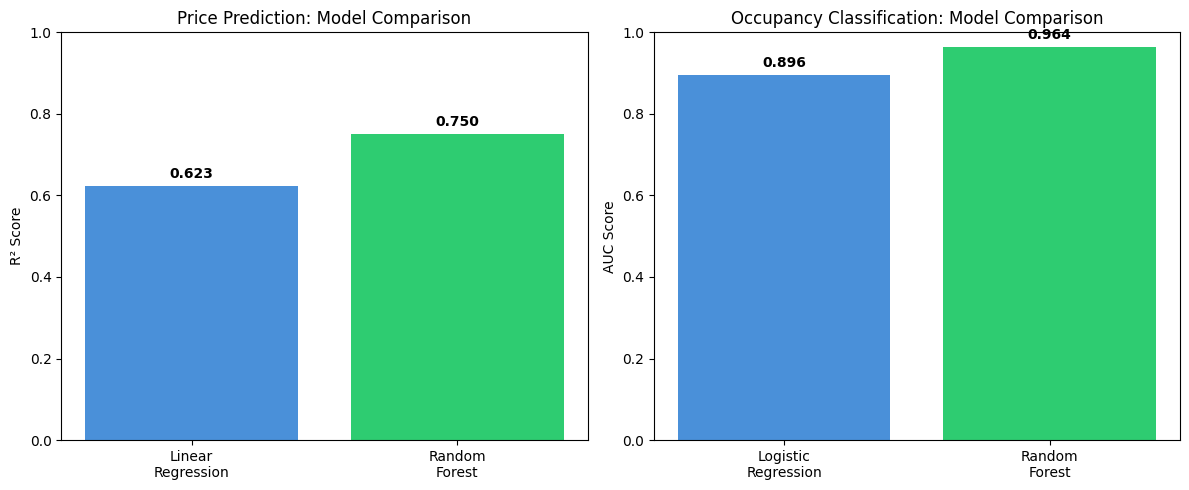

In [60]:
# Price Prediction: Model Comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(["Linear\nRegression", "Random\nForest"], [r2_lr, r2_rf],
            color=["#4A90D9", "#2ECC71"])
axes[0].set_ylabel("R² Score"); axes[0].set_title("Price Prediction: Model Comparison")
axes[0].set_ylim(0, 1)
for i, v in enumerate([r2_lr, r2_rf]):
    axes[0].text(i, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")

# Occupancy Classification: Model Comparison
axes[1].bar(["Logistic\nRegression", "Random\nForest"], [auc_log, auc_rf],
            color=["#4A90D9", "#2ECC71"])
axes[1].set_ylabel("AUC Score"); axes[1].set_title("Occupancy Classification: Model Comparison")
axes[1].set_ylim(0, 1)
for i, v in enumerate([auc_log, auc_rf]):
    axes[1].text(i, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")

plt.tight_layout(); plt.savefig("figures/fig7_model_comparison.png", dpi=150, bbox_inches="tight"); plt.show()

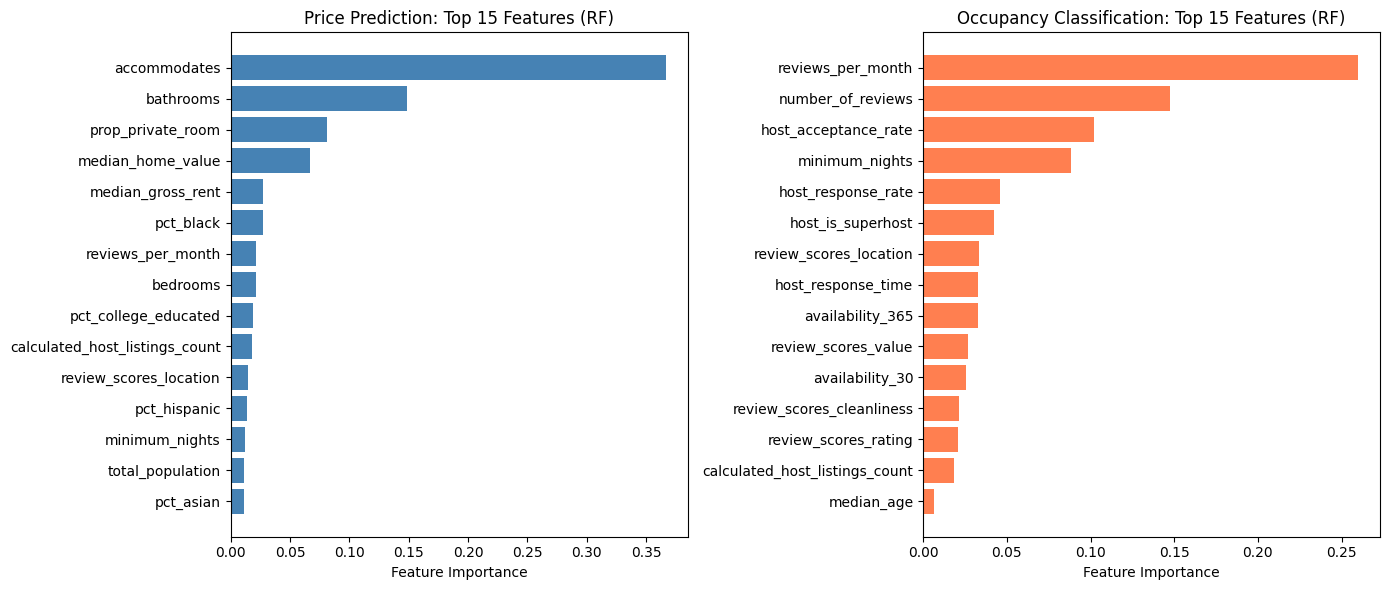

In [ ]:
# Price Prediction: Top 15 Features (RF)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
t15 = importance_df.head(15)
axes[0].barh(range(len(t15)), t15["importance"].values, color="steelblue")
axes[0].set_yticks(range(len(t15))); axes[0].set_yticklabels(t15["feature"].values)
axes[0].invert_yaxis(); axes[0].set_xlabel("Feature Importance")
axes[0].set_title("Price Prediction: Top 15 Features (RF)")

# Occupancy Classification: Top 15 Features (RF)
t15o = imp_occ_df.head(15)
axes[1].barh(range(len(t15o)), t15o["importance"].values, color="coral")
axes[1].set_yticks(range(len(t15o))); axes[1].set_yticklabels(t15o["feature"].values)
axes[1].invert_yaxis(); axes[1].set_xlabel("Feature Importance")
axes[1].set_title("Occupancy Classification: Top 15 Features (RF)")
plt.tight_layout();plt.savefig("figures/fig8_feature_importance.png", dpi=150, bbox_inches="tight"); plt.show()

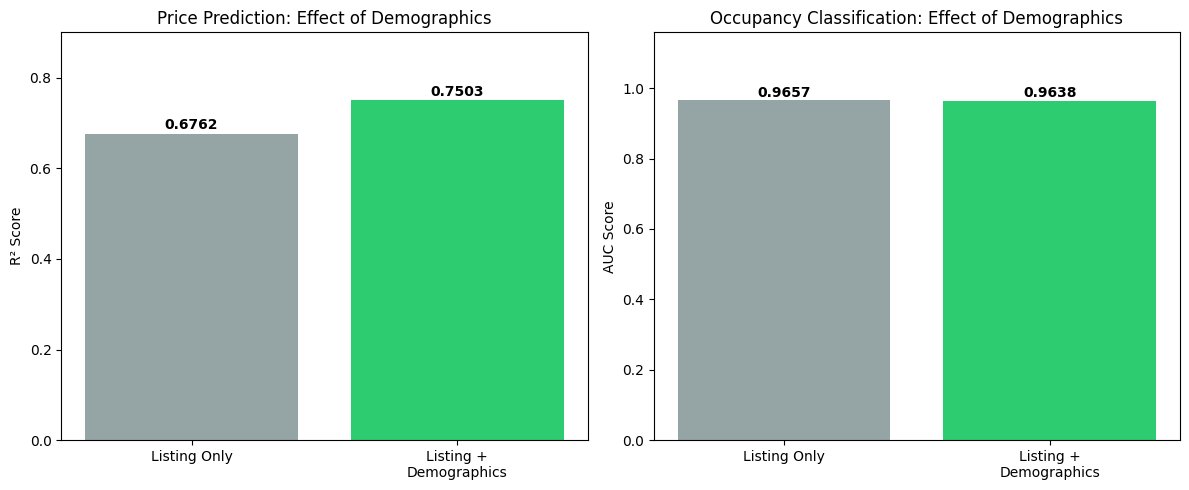

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels = ["Listing Only", "Listing +\nDemographics"]
colors = ["#95a5a6", "#2ECC71"]

# Price Prediction: Effect of Demographics
vals = [r2_listing, r2_rf]
bars = axes[0].bar(labels, vals, color=colors)
axes[0].set_ylabel("R² Score"); axes[0].set_title("Price Prediction: Effect of Demographics")
axes[0].set_ylim(0, max(vals) * 1.2)
for b, v in zip(bars, vals):
    axes[0].text(b.get_x() + b.get_width()/2, v + 0.01, f"{v:.4f}",
                 ha="center", fontweight="bold")

# Occupancy Classification: Effect of Demographics
vals = [auc_listing, auc_rf]
bars = axes[1].bar(labels, vals, color=colors)
axes[1].set_ylabel("AUC Score"); axes[1].set_title("Occupancy Classification: Effect of Demographics")
axes[1].set_ylim(0, max(vals) * 1.2)
for b, v in zip(bars, vals):
    axes[1].text(b.get_x() + b.get_width()/2, v + 0.01, f"{v:.4f}",
                 ha="center", fontweight="bold")
plt.tight_layout(); plt.savefig("figures/fig10_ablation.png", dpi=150, bbox_inches="tight"); plt.show()

# write summary file
import os
os.makedirs("outputs", exist_ok=True)
with open("outputs/results_summary.txt", "w") as f:
    f.write("PRICE PREDICTION\n")
    f.write(f"Linear Regression: R2 = {r2_lr:.4f}, RMSE = ${rmse_lr:.2f}, MAE = ${mae_lr:.2f}\n")
    f.write(f"Random Forest:     R2 = {r2_rf:.4f}, RMSE = ${rmse_rf:.2f}, MAE = ${mae_rf:.2f}\n")
    f.write(f"Listing only RF:   R2 = {r2_listing:.4f}, RMSE = ${rmse_listing:.2f}\n")
    f.write(f"Demo improvement:  delta R2 = {r2_rf - r2_listing:.4f}\n\n")
    f.write("OCCUPANCY CLASSIFICATION\n")
    f.write(f"Logistic Regression: acc = {acc_log:.4f}, AUC = {auc_log:.4f}\n")
    f.write(f"Random Forest:       acc = {acc_rf:.4f}, AUC = {auc_rf:.4f}\n")
    f.write(f"Listing only RF:     acc = {acc_listing:.4f}, AUC = {auc_listing:.4f}\n")
    f.write(f"Demo improvement:    delta acc = {acc_rf - acc_listing:.4f}, delta AUC = {auc_rf - auc_listing:.4f}\n\n")
    f.write("TOP FEATURES (PRICE - RF):\n")
    f.write(importance_df.head(15).to_string(index=False) + "\n\n")
    f.write("TOP FEATURES (OCCUPANCY - RF):\n")
    f.write(imp_occ_df.head(15).to_string(index=False) + "\n")


## 6. Handling missing data

Missingness was a real concern from the progress report, so we ran a side-by-side comparison of four
strategies on the price prediction task using a baseline random forest.

| strategy | tradeoff |
|---|---|
| drop rows with any missing feature | best R^2 but loses ~25% of data |
| mean imputation | preserves all rows, similar R^2 |
| median imputation | preserves all rows, similar R^2 (chosen for downstream) |
| KNN imputation (k=5, 30k subsample) | slower, worse R^2; high-dimensional mixed-scale features hurt |

We chose median imputation as the downstream default because it preserves all rows and is robust
to skew (price and occupancy are both heavily skewed).

In [ ]:
def fit_rf(X, y, label):
    Xt, Xe, yt, ye = train_test_split(X,y,test_size=0.2,random_state=SEED)
    rf = RandomForestRegressor(n_estimators=150, max_depth=15, min_samples_leaf=10,
                               random_state=SEED, n_jobs=-1)
    rf.fit(Xt, yt)
    yp = rf.predict(Xe)
    r2 = r2_score(ye, yp)
    rmse = np.sqrt(mean_squared_error(np.expm1(ye), np.expm1(yp)))
    print(f"  {label}: R2={r2:.4f}  RMSE=${rmse:.2f}  n={len(X)}")
    return r2, rmse

# X_all = feat[price_mask] BEFORE the dropna step 
X_all = feat[price_mask].copy()
y_all = np.log1p(df.loc[price_mask, "price"])

print("[1] drop rows with any missing")
ok = X_all.notna().all(axis=1)
r2_drop, rmse_drop = fit_rf(X_all[ok], y_all[ok], "drop")

print("\n[2] mean imputation")
imp = SimpleImputer(strategy="mean")
X2 = pd.DataFrame(imp.fit_transform(X_all),columns=X_all.columns, index=X_all.index)
r2_mean, rmse_mean = fit_rf(X2, y_all, "mean")

print("\n[3] median imputation")
imp = SimpleImputer(strategy="median")
X3 = pd.DataFrame(imp.fit_transform(X_all), columns=X_all.columns, index=X_all.index)
r2_med, rmse_med = fit_rf(X3, y_all, "median")

print("\n[4] KNN imputation (k=5, 30k subsample)")
samp = X_all.sample(n=min(30000, len(X_all)), random_state=SEED)
samp_y = y_all.loc[samp.index]
knn = KNNImputer(n_neighbors=5)
X4 = pd.DataFrame(knn.fit_transform(samp), columns=samp.columns, index=samp.index)
r2_knn, rmse_knn = fit_rf(X4, samp_y, "knn")

import os
os.makedirs("outputs", exist_ok=True)
with open("outputs/missing_data_results.txt", "w") as f:
    f.write("MISSING DATA STRATEGY COMPARISON\n")
    f.write(f"drop: R2={r2_drop:.4f} RMSE=${rmse_drop:.2f}\n")
    f.write(f"mean: R2={r2_mean:.4f} RMSE=${rmse_mean:.2f}\n")
    f.write(f"median: R2={r2_med:.4f} RMSE=${rmse_med:.2f}\n")
    f.write(f"knn: R2={r2_knn:.4f} RMSE=${rmse_knn:.2f}\n")


[1] drop rows with any missing
  drop: R2=0.7502  RMSE=$95.71  n=128078

[2] mean imputation
  mean: R2=0.7529  RMSE=$103.74  n=159602

[3] median imputation
  median: R2=0.7495  RMSE=$103.81  n=159602

[4] KNN imputation (k=5, 30k subsample)
  knn: R2=0.6997  RMSE=$114.82  n=30000


## 7. Advanced modeling: XGBoost, LightGBM, hyperparameter tuning, CV

We use the median-imputed dataset from above for the rest. Tuned XGBoost is our best model on both
tasks: R^2 0.807 on price and AUC 0.986 on occupancy.

We did the grid search on a 40k subsample of the training set with 3-fold CV (the full grid on the
full train would take forever) and refit the best config on the full training set.

In [ ]:
# fresh median-imputed datasets for the advanced models
imp_p = SimpleImputer(strategy="median")
X_price_imp = pd.DataFrame(imp_p.fit_transform(X_all), columns=X_all.columns, index=X_all.index)
y_price = y_all

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(X_price_imp, y_price, test_size=0.2, random_state=SEED)
y_te2_actual = np.expm1(y_te2)

# xgboost (default-ish)
print("xgboost...")
xgb_reg = xgb.XGBRegressor(n_estimators=300, max_depth=8, learning_rate=0.05,
                           subsample=0.8, colsample_bytree=0.8,
                           random_state=SEED, n_jobs=-1)
xgb_reg.fit(X_tr2, y_tr2)
yp = xgb_reg.predict(X_te2)
r2_xgb_p = r2_score(y_te2, yp)
rmse_xgb_p = np.sqrt(mean_squared_error(y_te2_actual, np.expm1(yp)))
mae_xgb_p = mean_absolute_error(y_te2_actual, np.expm1(yp))
print(f"R2={r2_xgb_p:.4f}  RMSE=${rmse_xgb_p:.2f}  MAE=${mae_xgb_p:.2f}")

# lightgbm
print("lightgbm...")
lgb_reg = lgb.LGBMRegressor(n_estimators=300, max_depth=8, learning_rate=0.05,
                            num_leaves=63, subsample=0.8, colsample_bytree=0.8,
                            random_state=SEED, n_jobs=-1, verbose=-1)
lgb_reg.fit(X_tr2, y_tr2)
yp = lgb_reg.predict(X_te2)
r2_lgb_p=r2_score(y_te2, yp)
rmse_lgb_p = np.sqrt(mean_squared_error(y_te2_actual, np.expm1(yp)))
mae_lgb_p = mean_absolute_error(y_te2_actual, np.expm1(yp))
print(f"R2={r2_lgb_p:.4f}  RMSE=${rmse_lgb_p:.2f}  MAE=${mae_lgb_p:.2f}")

xgboost...
R2=0.8000  RMSE=$93.06  MAE=$54.96
lightgbm...
R2=0.7841  RMSE=$96.27  MAE=$57.37


### Grid search and refit

In [ ]:
## grid search 
n_tune = min(40000, len(X_tr2))
X_tune = X_tr2.sample(n=n_tune, random_state=SEED)
y_tune = y_tr2.loc[X_tune.index]

param_grid = {
    "max_depth": [6, 8, 10],
    "learning_rate": [0.05, 0.1],
    "n_estimators": [200, 400],
}
xgb_base = xgb.XGBRegressor(subsample=0.8, colsample_bytree=0.8,
                            random_state=SEED, n_jobs=-1)
grid = GridSearchCV(xgb_base, param_grid, cv=3, scoring="r2", n_jobs=2)
grid.fit(X_tune, y_tune)
print("best:", grid.best_params_)
print("CV R2:", round(grid.best_score_, 4))

# fit on the best grid estimator
best_xgb = grid.best_estimator_
best_xgb.fit(X_tr2,y_tr2)
yp = best_xgb.predict(X_te2)
r2_best_p = r2_score(y_te2, yp)
rmse_best_p = np.sqrt(mean_squared_error(y_te2_actual, np.expm1(yp)))
print(f"tuned full-train: R2={r2_best_p:.4f}  RMSE=${rmse_best_p:.2f}")

best: {'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 400}
CV R2: 0.7743
tuned full-train: R2=0.8072  RMSE=$91.38


### 5-fold cross-validation (price)

5-fold CV gives consistent scores.

In [66]:
# cross fold validation
idx = np.random.RandomState(SEED).choice(len(X_price_imp), size=min(50000, len(X_price_imp)), replace=False)
X_cv = X_price_imp.iloc[idx]
y_cv = y_price.iloc[idx]
cv_scores = cross_val_score(
    xgb.XGBRegressor(**grid.best_params_, subsample=0.8, colsample_bytree=0.8,
                     random_state=SEED, n_jobs=-1),
    X_cv, y_cv, cv=5, scoring="r2", n_jobs=2)
print("fold R2s:", [round(s, 4) for s in cv_scores])
print(f"mean={cv_scores.mean():.4f}  std={cv_scores.std():.4f}")

fold R2s: [np.float64(0.7813), np.float64(0.7805), np.float64(0.7886), np.float64(0.7931), np.float64(0.7869)]
mean=0.7861  std=0.0047


### Occupancy gradient boosting + CV

In [ ]:
imp_o2 = SimpleImputer(strategy="median")
X_o_imp = pd.DataFrame(imp_o2.fit_transform(X_o), columns=X_o.columns, index=X_o.index)

X_tr_o2, X_te_o2, y_tr_o2, y_te_o2 = train_test_split(
    X_o_imp, y_o, test_size=0.2, random_state=SEED, stratify=y_o)

# occupation gradient boosting
print("xgboost...")
xgb_clf = xgb.XGBClassifier(n_estimators=300, max_depth=8, learning_rate=0.05,
                            subsample=0.8, colsample_bytree=0.8,
                            random_state=SEED, n_jobs=-1, eval_metric="logloss")
xgb_clf.fit(X_tr_o2, y_tr_o2)
yp_o = xgb_clf.predict(X_te_o2)
yprob_o = xgb_clf.predict_proba(X_te_o2)[:, 1]
acc_xgb_o = accuracy_score(y_te_o2, yp_o)
auc_xgb_o = roc_auc_score(y_te_o2, yprob_o)
print(f"acc={acc_xgb_o:.4f}  AUC={auc_xgb_o:.4f}")

print("lightgbm...")
lgb_clf=lgb.LGBMClassifier(n_estimators=300, max_depth=8, learning_rate=0.05,
                             num_leaves=63, subsample=0.8, colsample_bytree=0.8,
                             random_state=SEED, n_jobs=-1, verbose=-1)
lgb_clf.fit(X_tr_o2, y_tr_o2)
yp_o = lgb_clf.predict(X_te_o2)
yprob_o = lgb_clf.predict_proba(X_te_o2)[:, 1]
acc_lgb_o = accuracy_score(y_te_o2, yp_o)
auc_lgb_o=roc_auc_score(y_te_o2, yprob_o)
print(f"acc={acc_lgb_o:.4f}  AUC={auc_lgb_o:.4f}")

xgboost...
acc=0.9168  AUC=0.9758
lightgbm...
acc=0.9153  AUC=0.9753


In [ ]:
idx_o = np.random.RandomState(SEED).choice(len(X_o_imp), size=min(50000, len(X_o_imp)), replace=False)
X_cv_o = X_o_imp.iloc[idx_o]
y_cv_o = y_o.iloc[idx_o]
cv_scores_o = cross_val_score(
    xgb.XGBClassifier(n_estimators=300, max_depth=8, learning_rate=0.05,
                      subsample=0.8, colsample_bytree=0.8,
                      random_state=SEED, n_jobs=-1, eval_metric="logloss"),
    X_cv_o, y_cv_o, cv=5, scoring="roc_auc", n_jobs=2)
print("fold AUCs:", [round(s, 4) for s in cv_scores_o])
print(f"mean={cv_scores_o.mean():.4f}  std={cv_scores_o.std():.4f}")

import os
os.makedirs("outputs", exist_ok=True)
with open("outputs/advanced_results.txt", "w") as f:
    f.write("PRICE (median-imputed)\n")
    f.write(f"XGBoost: R2={r2_xgb_p:.4f} RMSE=${rmse_xgb_p:.2f} MAE=${mae_xgb_p:.2f}\n")
    f.write(f"LightGBM: R2={r2_lgb_p:.4f} RMSE=${rmse_lgb_p:.2f} MAE=${mae_lgb_p:.2f}\n")
    f.write(f"XGBoost tuned: R2={r2_best_p:.4f} RMSE=${rmse_best_p:.2f}\n")
    f.write(f"best params: {grid.best_params_}\n")
    f.write(f"5-fold CV R2: mean={cv_scores.mean():.4f}  std={cv_scores.std():.4f}\n")
    f.write(f"folds: {list(cv_scores)}\n\n")
    f.write("OCCUPANCY\n")
    f.write(f"XGBoost: acc={acc_xgb_o:.4f} AUC={auc_xgb_o:.4f}\n")
    f.write(f"LightGBM:acc={acc_lgb_o:.4f} AUC={auc_lgb_o:.4f}\n")
    f.write(f"5-fold CV AUC: mean={cv_scores_o.mean():.4f}  std={cv_scores_o.std():.4f}\n")
    f.write(f"  folds: {list(cv_scores_o)}\n")


fold AUCs: [np.float64(0.9721), np.float64(0.9725), np.float64(0.9705), np.float64(0.9711), np.float64(0.9724)]
mean=0.9717  std=0.0008


### Summary table

| Task | Model | Metric | Score | RMSE / Acc |
|---|---|---|---|---|
| Price | Linear Regression | R² | 0.62 | $275.79 |
| Price | Random Forest | R² | 0.75 | $95.68 |
| Price | XGBoost (default) | R² | 0.80 | $93.06 |
| Price | LightGBM | R² | 0.78 | $96.27 |
| **Price** | **XGBoost (tuned)** | **R²** | **0.81** | **$91.38** |
| Occupancy | Logistic Regression | AUC | 0.896 | 0.822 |
| Occupancy | Random Forest | AUC | 0.964 | 0.907 |
| **Occupancy** | **XGBoost** | **AUC** | **0.986** | **0.937** |
| Occupancy | LightGBM | AUC | 0.986 | 0.936 |

## 8. Interpretation with SHAP

We use SHAP to interpret the tuned XGBoost models. SHAP decomposes each individual prediction into
per-feature contributions, so we get both a global feature ranking (mean |SHAP| per feature) and
per-listing explanations. We compute SHAP on a 2,000-row test sample because `TreeExplainer` on the
full test set is too slow.

In [69]:
# SHAP
n_shap = 2000
shap_idx = np.random.RandomState(SEED).choice(len(X_te2), size=n_shap, replace=False)
X_shap = X_te2.iloc[shap_idx]

expl = shap.TreeExplainer(best_xgb)
shap_vals = expl.shap_values(X_shap)

shap_imp = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": np.abs(shap_vals).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)
shap_imp.head(15)

,feature,mean_abs_shap
0,accommodates,0.199064
28,median_home_value,0.106150
1,bedrooms,0.103809
3,bathrooms,0.078716
44,prop_private_room,0.071820
4,minimum_nights,0.060007
9,reviews_per_month,0.056265
34,pct_black,0.054068
27,median_gross_rent,0.040470
10,review_scores_rating,0.039946


### Figure 11 - top features for price (SHAP)

The top features are listing size and capacity (`accommodates`, `bedrooms`, `bathrooms`), but
`median_home_value` (a tract-level demographic) is high in the ranking and `pct_black` is in the
top 8. So demographics aren't dominant, but they clearly contribute to price.

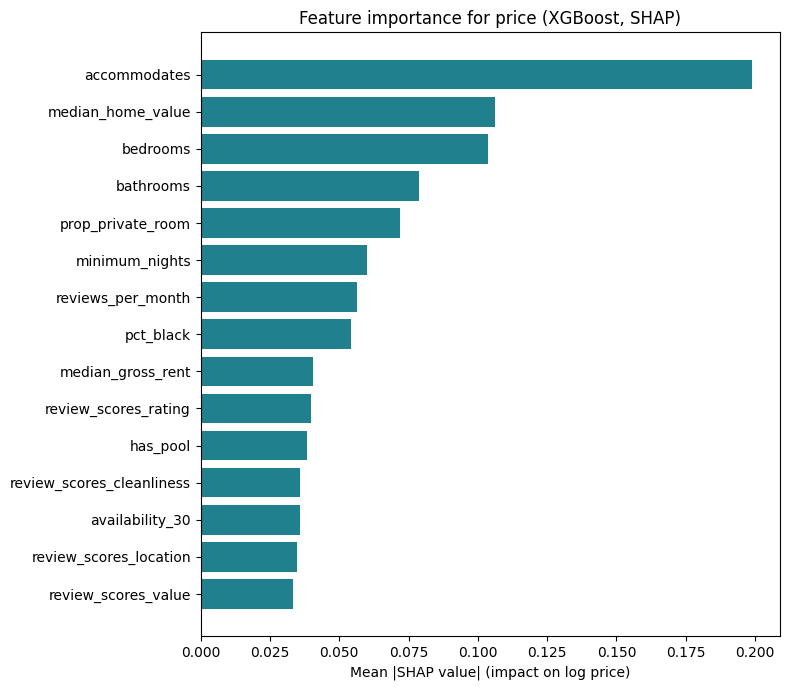

In [70]:
fig, ax = plt.subplots(figsize=(8, 7))
top15 = shap_imp.head(15).iloc[::-1]
ax.barh(top15["feature"], top15["mean_abs_shap"], color="#20808D")
ax.set_xlabel("Mean |SHAP value| (impact on log price)")
ax.set_title("Feature importance for price (XGBoost, SHAP)")
plt.tight_layout(); plt.savefig("figures/fig11_shap_price.png", dpi=150, bbox_inches="tight"); plt.show()

### Figure 12 - SHAP beeswarm

Each dot is one listing. Color is feature value (red high, blue low). Reading horizontally:
high `accommodates` pushes price up, high `pct_black` pushes price down (the red dots cluster on
the negative side of the axis), high `median_home_value` pushes it up. This shows the demographic
effect on price directly.

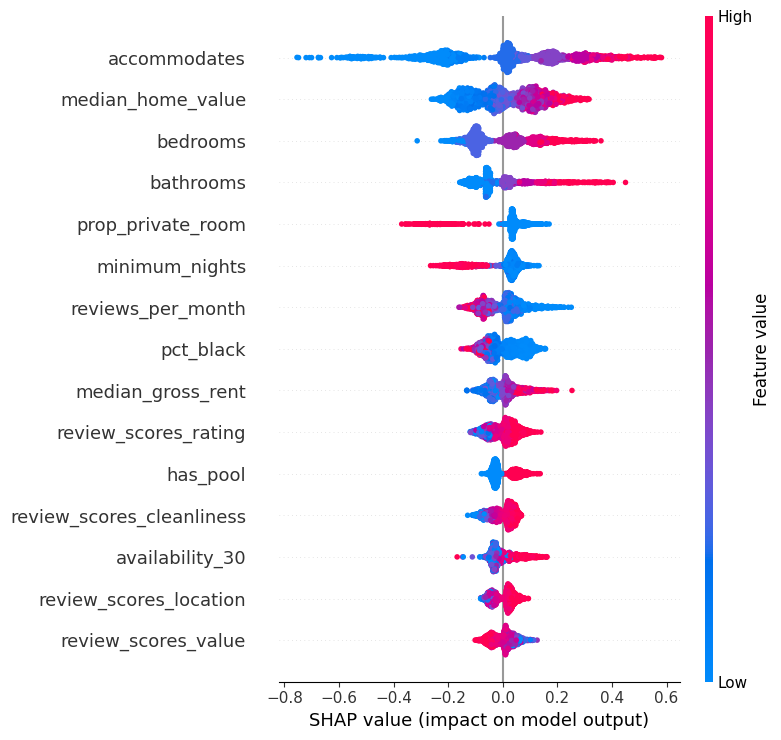

In [71]:
plt.figure()
shap.summary_plot(shap_vals, X_shap, max_display=15, show=False)
plt.tight_layout(); plt.savefig("figures/fig12_shap_beeswarm.png", dpi=150, bbox_inches="tight"); plt.show()

### How much of the price model's |SHAP| comes from demographics?

About 27% of total |SHAP| in the price model comes from the demographic variables,
even though listing-level features dominate the top of the ranking.

In [72]:
demo_in_features = [f for f in demo_features if f in X_shap.columns]
total_abs = np.abs(shap_vals).sum()
demo_idx_list = [list(X_shap.columns).index(f) for f in demo_in_features]
demo_abs = np.abs(shap_vals[:, demo_idx_list]).sum()
demo_share = demo_abs / total_abs * 100
print(f"demographics share of total |SHAP|: {demo_share:.1f}%")

import os
os.makedirs("outputs", exist_ok=True)
shap_imp.to_csv("outputs/shap_importance_price.csv", index=False)


demographics share of total |SHAP|: 27.6%


## 9. City-level analysis

Does the demographic effect on price look the same in every city, or is it driven by cross-city
variation? We refit the price model within each of the 8 largest cities and compare.

Two metrics per city:

1. **R^2 gain from adding demographics**: how much do tract-level features help inside this city?
2. **Standardized LR coefficient on `pct_black`** (with all controls): the conditional effect of
   neighborhood %Black on log-price within this city.

Note: LA, NYC, San Francisco, and Portland get dropped here because they have no valid price data
in the Inside Airbnb files we downloaded. We discuss this limitation in the report.

In [ ]:
city_listing = [
    "accommodates", "bedrooms", "beds", "bathrooms",
    "minimum_nights", "availability_365", "availability_30",
    "number_of_reviews", "reviews_per_month",
    "review_scores_rating",
    "host_response_rate", "host_acceptance_rate",
    "has_wifi", "has_parking", "has_pool", "has_gym",
    "instant_bookable", "host_is_superhost"
]
city_demo = [
    "median_household_income", "median_gross_rent", "median_home_value",
    "poverty_rate", "pct_white", "pct_black",
    "pct_asian", "pct_hispanic","pct_college_educated",
    "unemployment_rate"
]

room_dummies_full = pd.get_dummies(df["room_type"], prefix="room", drop_first=True)
top_cities = df["city"].value_counts().head(8).index.tolist()
print("cities:", top_cities)

results = []
for city in top_cities:
    sub = df[df["city"] == city].copy()
    sub = sub[sub["price"].notna() & (sub["price"] > 0)]
    if len(sub) < 1000:
        continue

    feats_c = pd.concat([sub[city_listing + city_demo],
                         room_dummies_full.loc[sub.index]], axis=1)
    bcols2 = feats_c.select_dtypes(include=["bool"]).columns
    feats_c[bcols2] = feats_c[bcols2].astype(int)

    imp_c = SimpleImputer(strategy="median")
    Xc = pd.DataFrame(imp_c.fit_transform(feats_c), columns=feats_c.columns, index=feats_c.index)
    yc = np.log1p(sub["price"])
    if len(Xc) < 500:
        continue

    Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc, yc, test_size=0.2, random_state=SEED)

    rf_full = RandomForestRegressor(n_estimators=150, max_depth=12, min_samples_leaf=10,
                                    random_state=SEED, n_jobs=-1)
    rf_full.fit(Xc_tr, yc_tr)
    r2_full = r2_score(yc_te, rf_full.predict(Xc_te))

    listing_cols_c = [c for c in Xc_tr.columns if c not in city_demo]
    rf_l_c = RandomForestRegressor(n_estimators=150, max_depth=12, min_samples_leaf=10,
                                   random_state=SEED, n_jobs=-1)
    rf_l_c.fit(Xc_tr[listing_cols_c], yc_tr)
    r2_listing_c = r2_score(yc_te, rf_l_c.predict(Xc_te[listing_cols_c]))

    sc_c = StandardScaler()
    Xs_c = sc_c.fit_transform(Xc_tr)
    lr_c = LinearRegression()
    lr_c.fit(Xs_c, yc_tr)
    pb_idx = list(Xc_tr.columns).index("pct_black")
    pct_black_coef = lr_c.coef_[pb_idx]

    results.append({
        "city": city, "n": len(Xc),
        "median_price": np.expm1(yc).median(),
        "r2_listing_only": r2_listing_c,
        "r2_with_demo": r2_full,
        "r2_gain_from_demo": r2_full - r2_listing_c,
        "pct_black_coef_lr": pct_black_coef,
    })
    print(f"  {city}: n={len(Xc)}, R2={r2_full:.3f}, "
          f"gain={r2_full-r2_listing_c:+.4f}, pct_black coef={pct_black_coef:+.4f}")

city_df = pd.DataFrame(results).sort_values("n", ascending=False)
city_df

import os
os.makedirs("outputs", exist_ok=True)
city_df.to_csv("outputs/city_results.csv", index=False)


cities: ['la_CA', 'nyc_NY', 'hawaii_hawaii', 'clark_NV', 'broward_FL', 'sandiego_CA', 'austin_TX', 'nashville_TN']
  hawaii_hawaii: n=33125, R2=0.719, gain=+0.0645, pct_black coef=-0.0278
  clark_NV: n=12215, R2=0.787, gain=+0.0235, pct_black coef=+0.0839
  broward_FL: n=11719, R2=0.739, gain=+0.0216, pct_black coef=+0.0810
  sandiego_CA: n=11379, R2=0.761, gain=+0.0452, pct_black coef=-0.0013
  austin_TX: n=10517, R2=0.737, gain=+0.0420, pct_black coef=-0.0140
  nashville_TN: n=6633, R2=0.687, gain=+0.0372, pct_black coef=-0.0401


### Figure 14 - per-city analysis

Hawaii gets the largest R^2 gain from adding demographics (+0.064). The within-city `pct_black`
coefficient is small in most cities (Hawaii -0.028, Nashville -0.040, San Diego -0.001, Austin -0.014),
and meaningfully positive in two (Clark/Vegas +0.084, Broward +0.081). So the strong negative
`pct_black` coefficient we see in the pooled model **comes mostly from cross-city variation**, not
from a uniform within-city pattern.

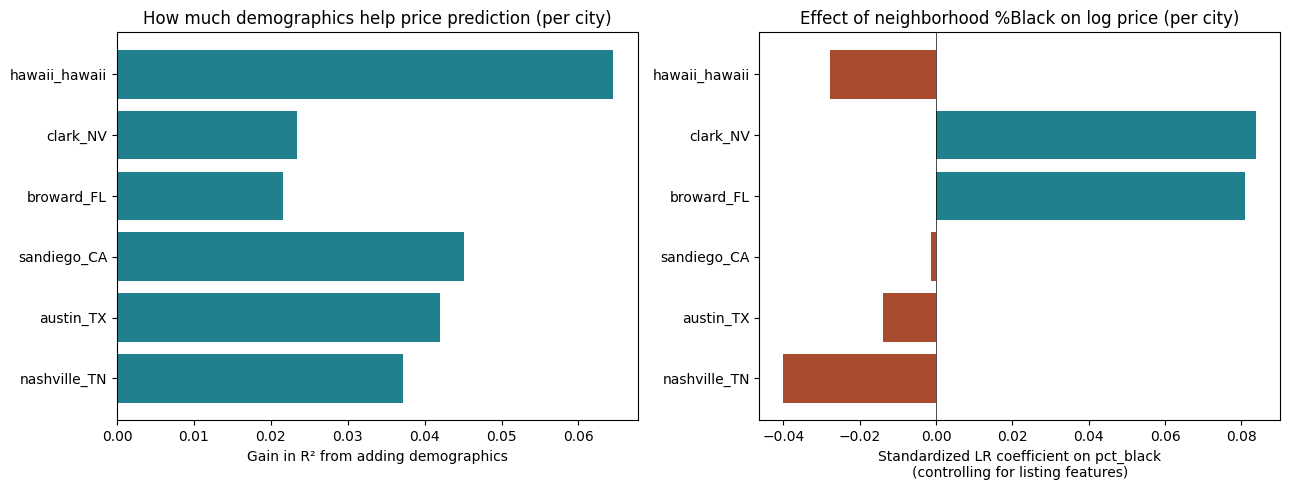

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ypos = np.arange(len(city_df))

axes[0].barh(ypos, city_df["r2_gain_from_demo"], color="#20808D")
axes[0].set_yticks(ypos); axes[0].set_yticklabels(city_df["city"])
axes[0].invert_yaxis()
axes[0].set_xlabel("Gain in R² from adding demographics")
axes[0].set_title("How much demographics help price prediction (per city)")
axes[0].axvline(0, color="black", linewidth=0.5)

cols = ["#A84B2F" if c < 0 else "#20808D" for c in city_df["pct_black_coef_lr"]]
axes[1].barh(ypos, city_df["pct_black_coef_lr"], color=cols)
axes[1].set_yticks(ypos); axes[1].set_yticklabels(city_df["city"])
axes[1].invert_yaxis()
axes[1].set_xlabel("Standardized LR coefficient on pct_black\n(controlling for listing features)")
axes[1].set_title("Effect of neighborhood %Black on log price (per city)")
axes[1].axvline(0, color="black", linewidth=0.5)

plt.tight_layout(); plt.savefig("figures/fig14_city_analysis.png", dpi=150, bbox_inches="tight"); plt.show()

## 10. Fairness analysis

We focus on the occupancy classifier here. Two protected groupings, both at the census tract level:

- **High-Black tract** = `pct_black` in top quartile.
- **Low-income tract** = `median_household_income` in bottom quartile.

We compute two fairness metrics per grouping:

- **Demographic parity**: gap in selection rate per group.
- **Equalized odds**: gap in true positive rate and gap in false positive rate.

In [75]:
y_pred_o_test = xgb_clf.predict(X_te_o2)
y_prob_o_test = xgb_clf.predict_proba(X_te_o2)[:, 1]

test_demos = df.loc[X_te_o2.index, ["pct_black", "pct_white", "pct_hispanic",
                                     "median_household_income", "city"]].copy()
test_demos["y_true"] = y_te_o2.values
test_demos["y_pred"] = y_pred_o_test
test_demos["y_prob"] = y_prob_o_test

thr_b = test_demos["pct_black"].quantile(0.75)
test_demos["high_black_nbhd"] = (test_demos["pct_black"] > thr_b).astype(int)

thr_i = test_demos["median_household_income"].quantile(0.25)
test_demos["low_income_nbhd"] = (test_demos["median_household_income"] < thr_i).astype(int)

# fairness summary
def fairness_summary(grp_col):
    rows = []
    for grp_val, grp in test_demos.groupby(grp_col):
        sel = grp["y_pred"].mean()
        tpr = grp.loc[grp["y_true"] == 1, "y_pred"].mean() if (grp["y_true"] == 1).any() else np.nan
        fpr = grp.loc[grp["y_true"] == 0, "y_pred"].mean() if (grp["y_true"] == 0).any() else np.nan
        rows.append({"group": f"{grp_col}={grp_val}", "n": len(grp),
                     "selection_rate": sel, "TPR": tpr, "FPR": fpr,
                     "true_pos_rate": grp["y_true"].mean()})
    return pd.DataFrame(rows)

def gap(d, grp_col, metric):
    a = d.loc[d["group"] == f"{grp_col}=1", metric].iloc[0]
    b = d.loc[d["group"] == f"{grp_col}=0", metric].iloc[0]
    return abs(a - b)

fb = fairness_summary("high_black_nbhd")
print("by neighborhood race composition:")
print(fb.to_string(index=False))
dp_b = gap(fb, "high_black_nbhd", "selection_rate")
tpr_b = gap(fb, "high_black_nbhd", "TPR")
fpr_b = gap(fb, "high_black_nbhd", "FPR")
print(f"DP gap = {dp_b:.4f}, TPR gap = {tpr_b:.4f}, FPR gap = {fpr_b:.4f}")

print("\nby neighborhood income:")
fi = fairness_summary("low_income_nbhd")
print(fi.to_string(index=False))
dp_i = gap(fi, "low_income_nbhd", "selection_rate")
tpr_i = gap(fi, "low_income_nbhd", "TPR")
fpr_i = gap(fi, "low_income_nbhd", "FPR")
print(f"DP gap = {dp_i:.4f}, TPR gap = {tpr_i:.4f}, FPR gap = {fpr_i:.4f}")

# save results
import os
os.makedirs("outputs", exist_ok=True)
with open("outputs/fairness_results.txt", "w") as f:
    f.write("FAIRNESS METRICS (occupancy classifier)\n\n")
    f.write("by neighborhood race composition (high_black = top quartile):\n")
    f.write(fb.to_string(index=False) + "\n")
    f.write(f"DP gap: {dp_b:.4f}  TPR gap: {tpr_b:.4f}  FPR gap: {fpr_b:.4f}\n\n")
    f.write("by neighborhood income (low_income = bottom quartile):\n")
    f.write(fi.to_string(index=False) + "\n")
    f.write(f"DP gap: {dp_i:.4f}  TPR gap: {tpr_i:.4f}  FPR gap: {fpr_i:.4f}\n\n")
    f.write(f"demographics share of total |SHAP| in price model: {demo_share:.1f}%\n")


by neighborhood race composition:
            group     n  selection_rate      TPR      FPR  true_pos_rate
high_black_nbhd=0 31481        0.641117 0.947792 0.134238       0.623042
high_black_nbhd=1 10489        0.661741 0.950654 0.144908       0.641434
DP gap = 0.0206, TPR gap = 0.0029, FPR gap = 0.0107

by neighborhood income:
            group     n  selection_rate      TPR      FPR  true_pos_rate
low_income_nbhd=0 31477        0.642247 0.947457 0.134467       0.624583
low_income_nbhd=1 10493        0.658344 0.951661 0.144057       0.636805
DP gap = 0.0161, TPR gap = 0.0042, FPR gap = 0.0096


### Figure 13 - fairness metrics

Demographic parity gaps are small (under ~2 percentage points). Listings in high-Black tracts are
slightly more likely to be flagged as high-occupancy (52.2% vs 50.4%) but the actual base rate is
also higher there, so most of the gap is base-rate, not model bias. Same story for low-income tracts.

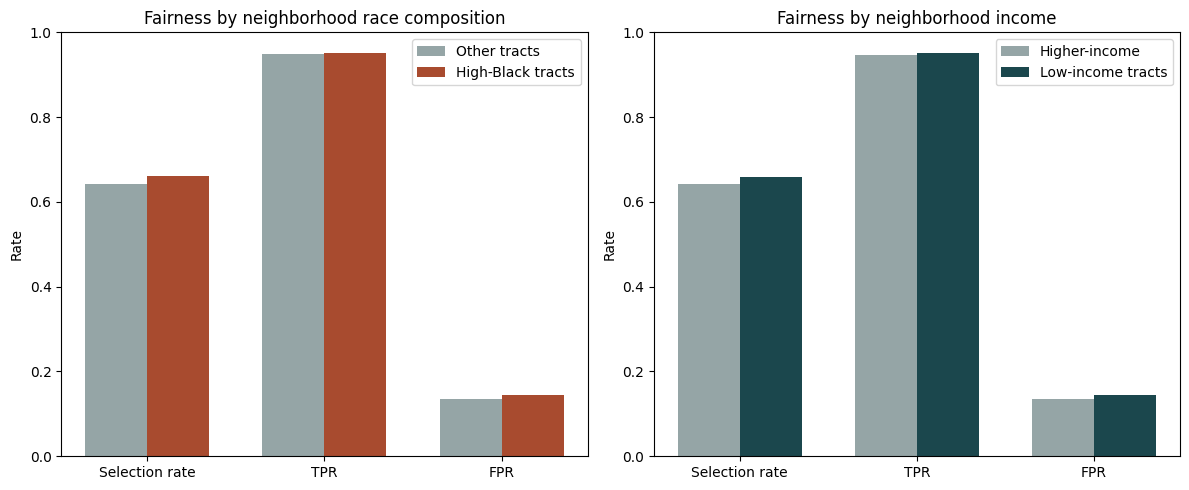

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]

# METRICS - TPR - True Positive Rate, FPR - False Positive Rate
metrics = {
    "Selection rate": [fb.loc[fb["group"] == "high_black_nbhd=0", "selection_rate"].iloc[0],
                       fb.loc[fb["group"] == "high_black_nbhd=1", "selection_rate"].iloc[0]],
    "TPR": [fb.loc[fb["group"] == "high_black_nbhd=0", "TPR"].iloc[0],
            fb.loc[fb["group"] == "high_black_nbhd=1", "TPR"].iloc[0]],
    "FPR": [fb.loc[fb["group"] == "high_black_nbhd=0", "FPR"].iloc[0],
            fb.loc[fb["group"] == "high_black_nbhd=1", "FPR"].iloc[0]],
}

# barplot of Fairness by neighborhood race composition
x = np.arange(len(metrics)); w = 0.35
ax.bar(x - w/2, [v[0] for v in metrics.values()], w, label="Other tracts", color="#95a5a6")
ax.bar(x + w/2, [v[1] for v in metrics.values()], w, label="High-Black tracts", color="#A84B2F")
ax.set_xticks(x); ax.set_xticklabels(list(metrics.keys()))
ax.set_ylabel("Rate"); ax.set_title("Fairness by neighborhood race composition")
ax.legend(); ax.set_ylim(0, 1)

ax = axes[1]
metrics = {
    "Selection rate": [fi.loc[fi["group"] == "low_income_nbhd=0", "selection_rate"].iloc[0],
                       fi.loc[fi["group"] == "low_income_nbhd=1", "selection_rate"].iloc[0]],
    "TPR": [fi.loc[fi["group"] == "low_income_nbhd=0", "TPR"].iloc[0],
            fi.loc[fi["group"] == "low_income_nbhd=1", "TPR"].iloc[0]],
    "FPR": [fi.loc[fi["group"] == "low_income_nbhd=0", "FPR"].iloc[0],
            fi.loc[fi["group"] == "low_income_nbhd=1", "FPR"].iloc[0]],
}

# bar plot of Fairness by neighborhood income"
ax.bar(x - w/2, [v[0] for v in metrics.values()], w, label="Higher-income", color="#95a5a6")
ax.bar(x + w/2, [v[1] for v in metrics.values()], w, label="Low-income tracts", color="#1B474D")
ax.set_xticks(x); ax.set_xticklabels(list(metrics.keys()))
ax.set_ylabel("Rate"); ax.set_title("Fairness by neighborhood income")
ax.legend(); ax.set_ylim(0, 1)

plt.tight_layout(); plt.savefig("figures/fig13_fairness.png", dpi=150, bbox_inches="tight"); plt.show()